### Imports

In [26]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
from extraction_1D import run_1d_pipeline
from scipy.ndimage import affine_transform

### STEP 1: load CSD image, SVM model and json labels

In [27]:

# 1. setup paths 
# SVM model, go up one level with '../'
MODEL_PATH = "../classifier_training/svm_model.pkl"

# new images and labels are right in this folder
IMG_DIR = "csd_images"
LBL_DIR = "csd_labels"

# first test image 
TEST_IMAGE_NAME = "navtest_001_alpha0.251_wobble19.4.png" 
TEST_JSON_NAME = TEST_IMAGE_NAME.replace(".png", ".json")

# 2. load the Trained SVM Pipeline
with open(MODEL_PATH, "rb") as f:
    pipeline = pickle.load(f)
print("YES: SVM Pipeline loaded successfully.")

# 3. load the Test Image & Convert to Grayscale
# its a must toprocess the image EXACTLY how the SVM was trained
def load_image_gray(path: str) -> np.ndarray:
    img = plt.imread(path)
    if img.ndim == 3:
        # Collapse RGBA to luminance 
        gray = 0.2989 * img[:, :, 0] + 0.5870 * img[:, :, 1] + 0.1140 * img[:, :, 2]
    else:
        gray = img.astype(np.float32)
    return gray.astype(np.float32)

img_path = os.path.join(IMG_DIR, TEST_IMAGE_NAME)
img = load_image_gray(img_path)
print(f"YES: Loaded test image: {TEST_IMAGE_NAME} (Shape: {img.shape})")

# 4. load the Ground Truth (1,1) Coordinates from JSON
json_path = os.path.join(LBL_DIR, TEST_JSON_NAME)

with open(json_path, "r") as f:
    data = json.load(f)
    
true_target = data.get("target_pixel")
if true_target:
    true_x = true_target["col_px"]
    true_y = true_target["row_px"]
    print(f"YES: Ground Truth (1,1) Target is at: X={true_x}, Y={true_y}")
else:
    print("NO: Warning: No (1,1) target found in this JSON.")

YES: SVM Pipeline loaded successfully.
YES: Loaded test image: navtest_001_alpha0.251_wobble19.4.png (Shape: (500, 500))
YES: Ground Truth (1,1) Target is at: X=299, Y=199


### STEP 2: Run 1D extraction on the CSD and extract the matrix 

Detected row peaks: 5
Detected col peaks: 5
Total detected points from multi-slice: 551
Inliers: 86 / 551
Slope: 0.2711
~~~~~~~~~~ PASS 1: Diagonal Lines ~~~~~~~~~~~~~
Found diagonal line with 93 points (slope: 0.27)
Found diagonal line with 91 points (slope: 0.28)
Found diagonal line with 79 points (slope: 0.26)

~~~~~~~~~~ PASS 2: Steep Lines ~~~~~~~~~~~~~
Found steep line with 72 points (slope: 3.58)
Found steep line with 68 points (slope: 3.67)

Total lines found: 5


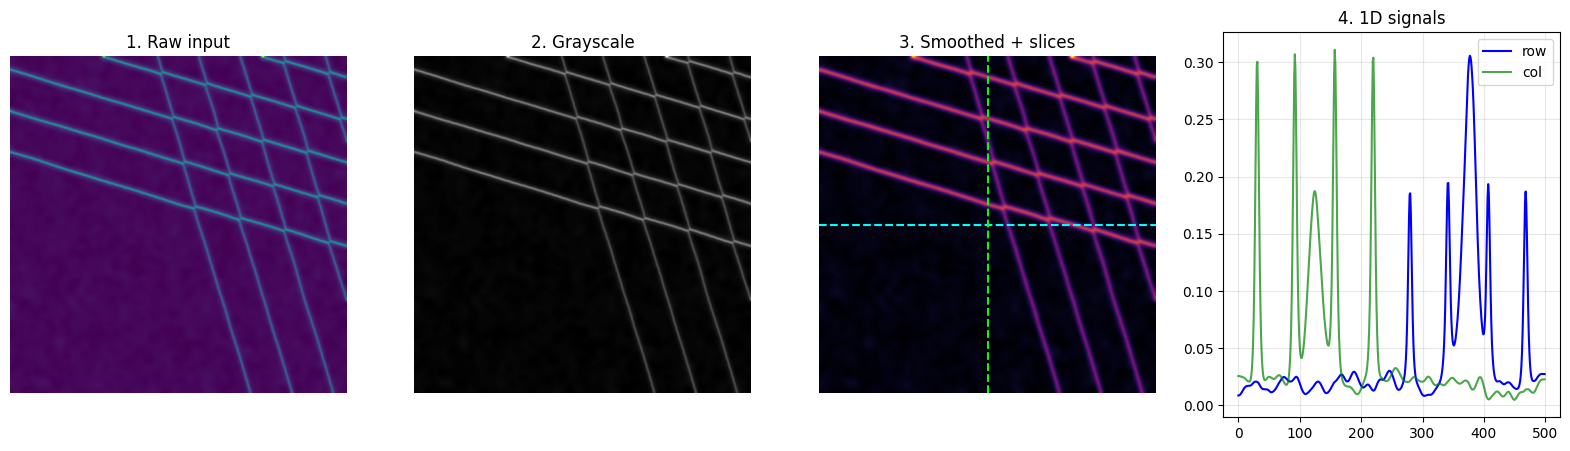

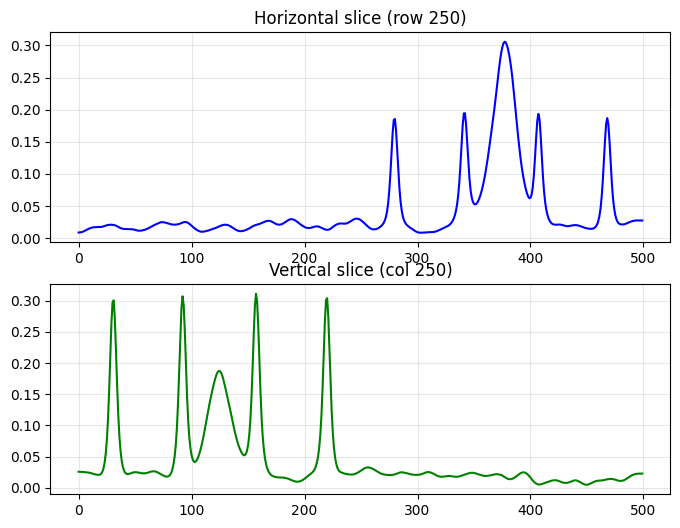

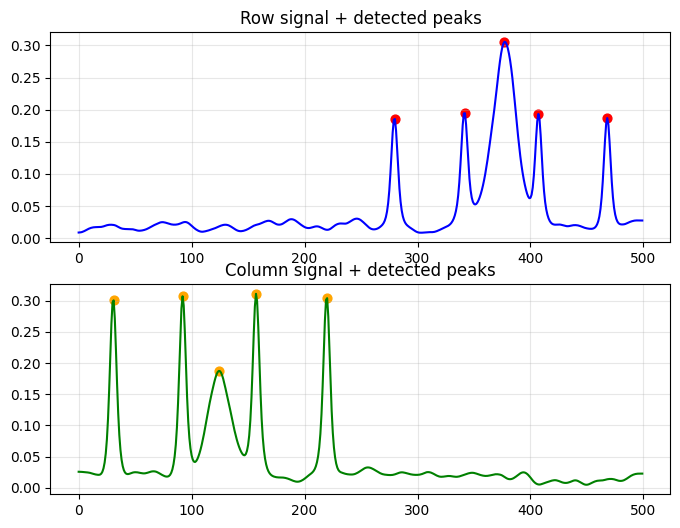

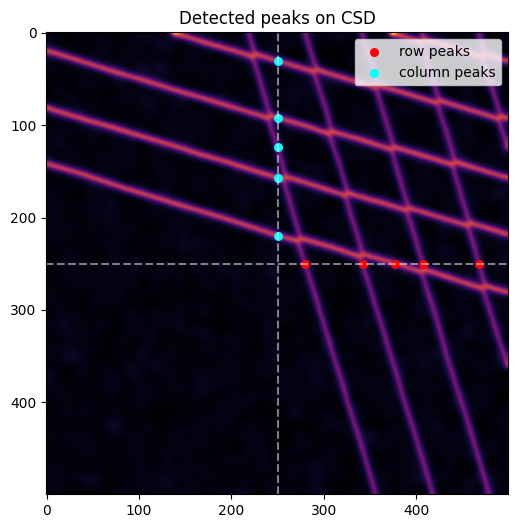

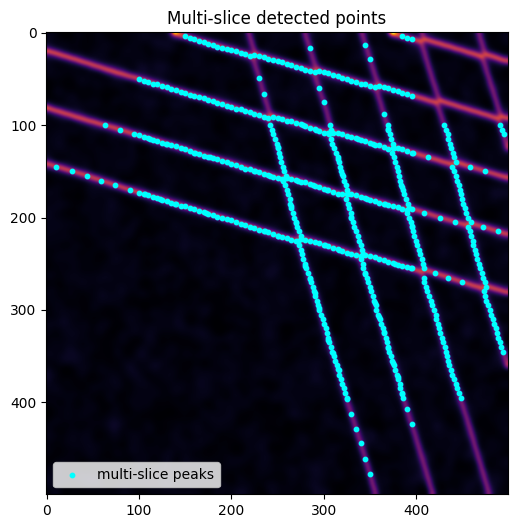

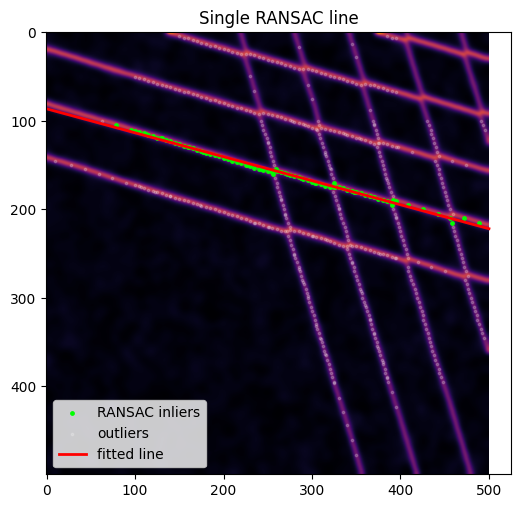

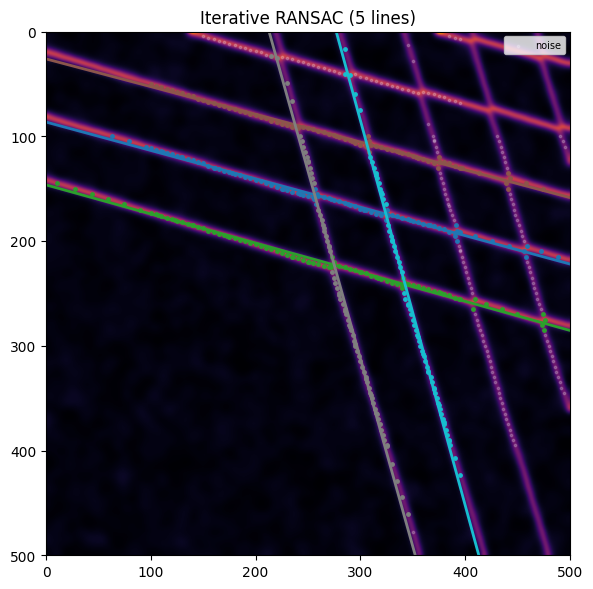

Saved iterative RANSAC result
Diagonal lines: 3
Steep lines: 2


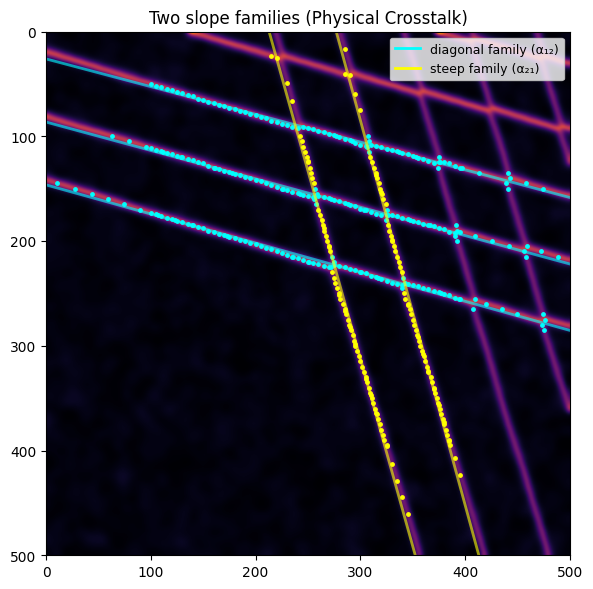

Displayed two slope families visualization with custom legend

Final extracted lines:
diagonal | slope = 0.2710 | points = 93
diagonal | slope = 0.2778 | points = 91
diagonal | slope = 0.2646 | points = 79
steep    | slope = 3.5829 | points = 72
steep    | slope = 3.6731 | points = 68

Filtered lines:
diagonal | slope = 0.2710 | points = 93
diagonal | slope = 0.2778 | points = 91
diagonal | slope = 0.2646 | points = 79
steep    | slope = 3.5829 | points = 72
steep    | slope = 3.6731 | points = 68
Rejected 0 outlier lines thru MAD.


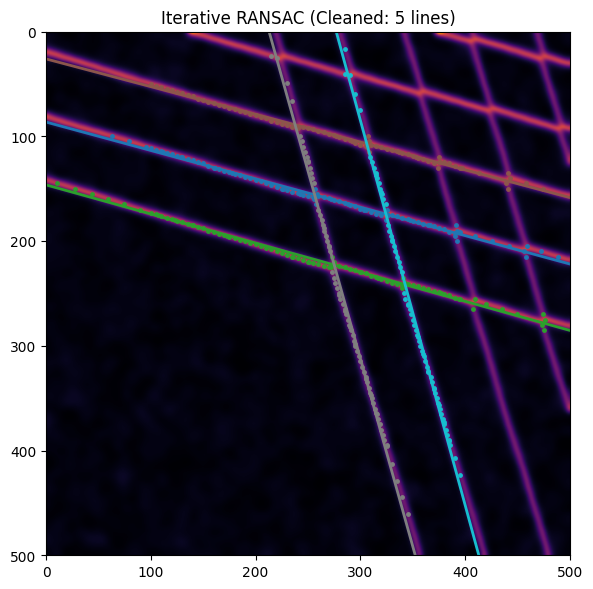

Displayed regenerated clean iterative RANSAC plot

FINAL RESULTS:
Diagonal slope (mean): 0.2711
Diagonal std: 0.0054
Steep slope (mean): 3.6280
Steep std: 0.0451
Slope ratio (s2/s1 = α21/α12 product ): 13.38
   diagonal α ≈ 0.2711  (input Cgd crosstalk was 0.25)
   steep α    ≈ 0.2756  (expected ~0.25 from symmetry)
1D Feature Extraction Complete!!!!!

 Navigation Vectors Acquired.
   v1 (Diagonal Step): [0.9652, 0.2617]
   v2 (Steep Step):    [0.2657, 0.9640]


In [28]:
# pass 'img' (from Cell 1) into the function
M, m1, m2, v1, v2 = run_1d_pipeline(img)

print(f"\n Navigation Vectors Acquired.")
print(f"   v1 (Diagonal Step): [{v1[0]:.4f}, {v1[1]:.4f}]")
print(f"   v2 (Steep Step):    [{v2[0]:.4f}, {v2[1]:.4f}]")



### STEP 3: Use Matrix to calculate safe steps inside the CSD. 

The CSD is slanted. If navigator wants to move from empty state to (1,1), it can't just move diagonally bc of cross-capacitance. So, this step creates some points over the image where the navigator can ofc "navigate" to. 

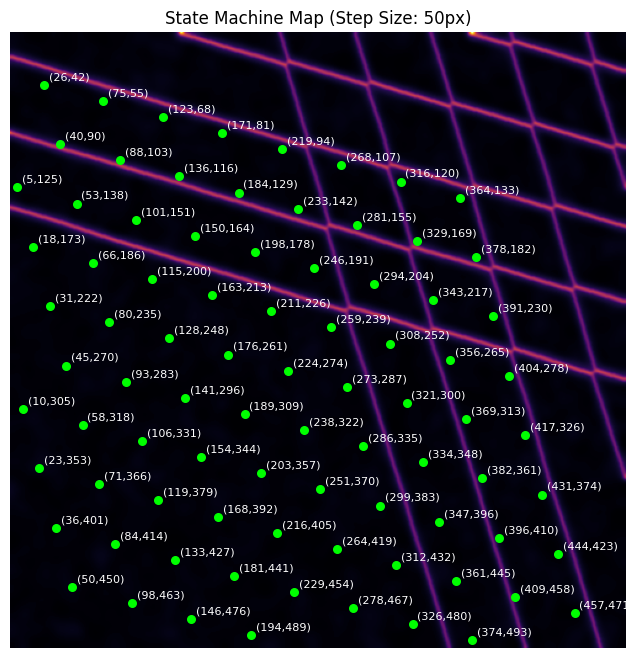

✅ State machine mapped! 84 safe states generated.


In [ ]:

# 1. def State Machine param
h, w = img.shape
origin_px = np.array([50, 450]) # home state (0,0) near the bottom-left
step_size = 50                  # pixel distance 
max_steps = 10                  # How many states to map in each direction

valid_points = []
labels = []

# 2. map the State Machine 
for i in range(max_steps):      # transitions along virtual gate 1
    for j in range(max_steps):  # transitions along virtual gate 2
        
        # vector addition: Start + (steps * v1) - (steps * v2)
        # y is subtracted because pixel coordinates start with 0 at the top
        point = origin_px + (i * step_size * v1) - (j * step_size * v2)
        
        x, y = point[0], point[1]
        
        # 3. Safety Boundary Filtering
        # keep the state only if it physically lands on the screen
        if 0 <= x < w and 0 <= y < h:
            valid_points.append([x, y])
            # actual integer pixel coordinates
            x, y = int(point[0]), int(point[1]) 
            labels.append(f"({x},{y})")

valid_points = np.array(valid_points)

# 4. save and overlay
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img, cmap="inferno")

# plot the safe state coordinates
if len(valid_points) > 0:
    ax.scatter(valid_points[:, 0], valid_points[:, 1], color="lime", s=30, zorder=2)
    
    # draw the state names (i, j) next to the dots so you can see the machine
    for pt, lbl in zip(valid_points, labels):
        ax.text(pt[0] + 4, pt[1] - 4, lbl, color="white", fontsize=8, zorder=3)

ax.set_title(f"State Machine Map (Step Size: {step_size}px)")
ax.axis("off")
plt.show()

print(f"✅ State machine mapped! {len(valid_points)} safe states generated.")